In [11]:
from skimage import io, color
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = io.imread("../data/DTUSigns2.jpg")

print(img.shape)

(3024, 4032, 3)


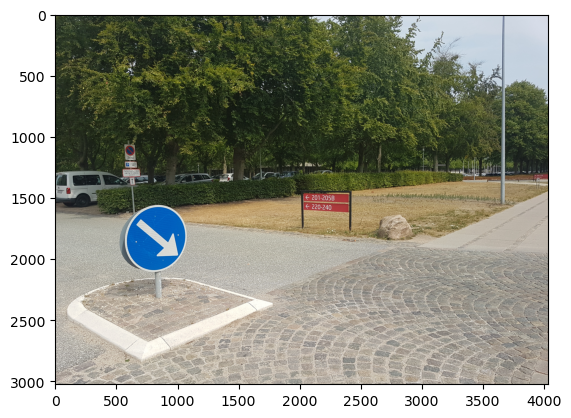

In [12]:
plt.imshow(img)

In [13]:
def detect_dtu_signs(img, color="blue"):
    segm_blue = 0
    if color == "red":
        r_comp = img[:, :, 0]
        g_comp = img[:, :, 1]
        b_comp = img[:, :, 2]
        segm_blue = (r_comp > 160) & (r_comp < 180) & (g_comp > 50) & (g_comp < 70) & \
                    (b_comp > 50) & (b_comp < 70)
    elif color == "blue":
        r_comp = img[:, :, 0]
        g_comp = img[:, :, 1]
        b_comp = img[:, :, 2]
        segm_blue = (r_comp < 10) & (g_comp > 85) & (g_comp < 105) & \
                (b_comp > 180) & (b_comp < 200)
    return segm_blue

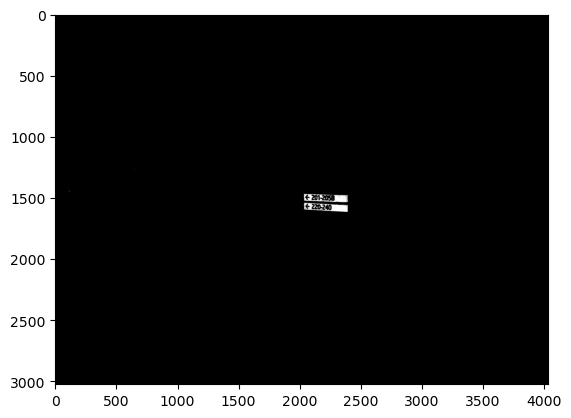

In [14]:
img_sign = detect_dtu_signs(img, color="red")
plt.imshow(img_sign, cmap="gray")

/tmp/ipykernel_105388/2098918178.py:16: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


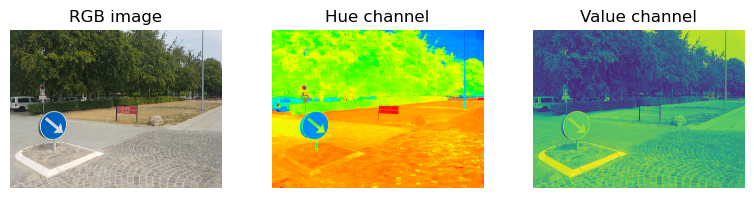

In [16]:
hsv_img = color.rgb2hsv(img)
hue_img = hsv_img[:, :, 0]
value_img = hsv_img[:, :, 2]
fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(8, 2))
ax0.imshow(img)
ax0.set_title("RGB image")
ax0.axis('off')
ax1.imshow(hue_img, cmap='hsv')
ax1.set_title("Hue channel")
ax1.axis('off')
ax2.imshow(value_img)
ax2.set_title("Value channel")
ax2.axis('off')

fig.tight_layout()
io.show()

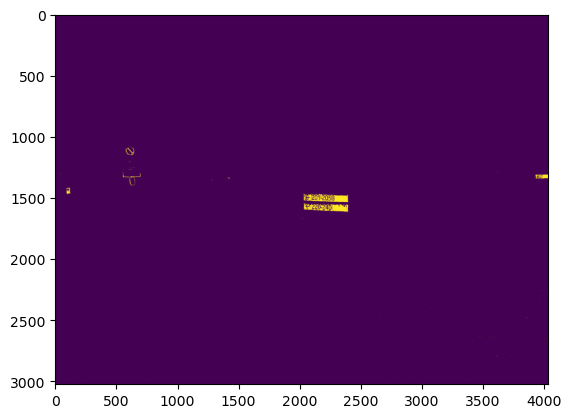

In [18]:
sign_hsv_img = hue_img > 0.97
plt.imshow(sign_hsv_img)